In [1]:
## Vloco de codigo para instalar versao especifica dos pacotes
##pip install pandas==1.5.3
##pip install numpy==1.24.3

In [2]:
import sys
import os

# Acesso aos módulos do diretório
from pathlib import Path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
print("Project root:", project_root)

Project root: C:\pod\hackathon_pod_2025


##### Carregando pacotes

In [3]:
# Pacotes de manipulacao

import pandas as pd
import numpy as np
import os

# Pacotes de visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

# Funcoes customizadas
import configs.function_basic as funcoes

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 1.5.3
numpy: 1.26.4


## Carregando databases

#### Book_03

In [4]:
# Carregando book_03
book_03 = pd.read_parquet(project_root/'database/processed/book_variaveis_03.parquet')
print("Book 03 data shape:", book_03.shape)

Book 03 data shape: (1280828, 96)


In [5]:
book_03.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280828 entries, 0 to 1280827
Data columns (total 96 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   SAFRA              1280828 non-null  int64         
 1   FPD                1280828 non-null  int64         
 2   SCORE_01           1273364 non-null  float64       
 3   SCORE_02           1280256 non-null  float64       
 4   NUM_CPF            1280828 non-null  object        
 5   SCORE_RATEO        1272792 non-null  float64       
 6   SCORE_AVG          1272792 non-null  float64       
 7   SCORE_DIFF         1272792 non-null  float64       
 8   SCORE_MIN          1280828 non-null  float64       
 9   DATADENASCIMENTO   1280828 non-null  datetime64[ns]
 10  var_03             1198460 non-null  object        
 11  var_04             1280828 non-null  object        
 12  var_05             1228039 non-null  object        
 13  var_09             600120 n

#### Base Recarga

In [6]:
## Carregando todos arquivos em parquet de uma pasta

pasta = project_root / 'database/raw/bases_recarga/bases_recarga/BI_FP_ASS_RECARGA_CMV_NOVA/'

all_files = [str(pasta / f) for f in os.listdir(pasta) if f.endswith('.parquet')]

print(f'{len(all_files)} arquivos encontrados')

df_list = [pd.read_parquet(f, engine='pyarrow') for f in all_files]
df_dados_recarga = pd.concat(df_list, ignore_index=True)
print('Base Dados Recarga data shape:', df_dados_recarga.shape)

10 arquivos encontrados
Base Dados Recarga data shape: (100213651, 24)


In [7]:
df_dados_recarga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100213651 entries, 0 to 100213650
Data columns (total 24 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   NUM_CPF                object
 1   DW_NUM_NTC             object
 2   DAT_INSERCAO_CREDITO   object
 3   HOR_INSERCAO_CREDITO   object
 4   DW_NUM_CLIENTE         object
 5   COD_TECNOLOGIA_DW      object
 6   COD_CANAL_AQUISICAO    object
 7   COD_TIPO_CREDITO       object
 8   COD_PROMOCAO           object
 9   VAL_CREDITO_INSERIDO   object
 10  VAL_BONUS              object
 11  VAL_REAL               object
 12  COD_PLATAFORMA_ATU     object
 13  COD_STATUS_PLATAFORMA  object
 14  IND_METODO_PAGAMENTO   object
 15  DW_PLANO_TARIFACAO     object
 16  DW_TIPO_RECARGA        object
 17  DW_TIPO_INSERCAO       object
 18  DW_FORMA_PAGAMENTO     object
 19  DW_INSTITUICAO         object
 20  COD_GRUPO_CARTAO       object
 21  DSC_GRUPO_CARTAO_WPP   object
 22  FLAG_SOS               object
 23  VAL

#### Ajuste no Dataset de Recargas

Para diminuir o tamanho da base processada e focarmos no nosso problema de negócio, iremos filtrar apenas os CPFs que estão na base do `book_03`

Também iremos criar a coluna `SAFRA` a partir da coluna `DAT_INSERCAO_CREDITO`

In [8]:
df_dados_recarga

,NUM_CPF,DW_NUM_NTC,DAT_INSERCAO_CREDITO,HOR_INSERCAO_CREDITO,DW_NUM_CLIENTE,COD_TECNOLOGIA_DW,COD_CANAL_AQUISICAO,COD_TIPO_CREDITO,COD_PROMOCAO,VAL_CREDITO_INSERIDO,...,IND_METODO_PAGAMENTO,DW_PLANO_TARIFACAO,DW_TIPO_RECARGA,DW_TIPO_INSERCAO,DW_FORMA_PAGAMENTO,DW_INSTITUICAO,COD_GRUPO_CARTAO,DSC_GRUPO_CARTAO_WPP,FLAG_SOS,VALOR_SOS
0,89UU788W7TW,712481754,09OCT2023:00:00:00,170410,1369129520,GSM,17598,PE,-1,20.00,...,A,606234,-2,-2,-2,-2,UB,Rec.Online,0,None
1,Z9Y7Y9ZNN9T,799107776,25MAR2025:00:00:00,65703,1491240998,GSM,-2,PE,-1,0.00,...,A,369889,-2,-2,-2,-2,FT,NaoSeAplica,0,None
2,W7T8UNX9878,739450945,12MAR2025:00:00:00,32753,1486001611,GSM,-3,PE,-1,0.00,...,A,668900,-2,-2,-2,-1,WT,NaoSeAplica,0,None
3,X87NNXNT8ZN,763847287,12FEB2024:00:00:00,124755,1437663095,GSM,-3,PE,-1,0.00,...,A,541200,-2,-2,-2,-1,PY,NaoSeAplica,0,None
4,ZXZ7UTU9U7W,778845955,17DEC2024:00:00:00,151109,1460735683,GSM,15987,PE,-1,25.00,...,A,668901,-2,-2,-2,14434,UC,Rec.Online,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100213646,ZZY888UZTX8,786838517,03DEC2024:00:00:00,25716,1473038284,GSM,-3,PE,-1,0.00,...,A,668900,-2,-2,-2,-1,WT,NaoSeAplica,0,None
100213647,U9WZ7ZZW88Y,762998383,05JUN2024:00:00:00,231325,1436548485,GSM,-3,PE,-1,0.00,...,A,541200,-2,-2,-2,-1,I8,AtivPromocao,0,None
100213648,7ZNWN78UUY8,615138814,22DEC2024:00:00:00,23127,1467434479,GSM,-3,PE,-1,0.00,...,A,668900,-2,-2,-2,-1,WT,NaoSeAplica,0,None
100213649,ZWN8U7ZNXZ8,757113250,02SEP2024:00:00:00,132406,1427346565,GSM,-3,PE,-1,0.00,...,A,541200,-2,-2,-2,-1,FU,NaoSeAplica,0,None


In [9]:
selecao_publico = book_03['NUM_CPF'].drop_duplicates()

# Selecionando na base de recarga apenas os CPFs presentes na base de score bureau movel
df_base_recarga_selecionada = df_dados_recarga[df_dados_recarga['NUM_CPF'].isin(selecao_publico)]
df_base_recarga_selecionada.head()

,NUM_CPF,DW_NUM_NTC,DAT_INSERCAO_CREDITO,HOR_INSERCAO_CREDITO,DW_NUM_CLIENTE,COD_TECNOLOGIA_DW,COD_CANAL_AQUISICAO,COD_TIPO_CREDITO,COD_PROMOCAO,VAL_CREDITO_INSERIDO,...,IND_METODO_PAGAMENTO,DW_PLANO_TARIFACAO,DW_TIPO_RECARGA,DW_TIPO_INSERCAO,DW_FORMA_PAGAMENTO,DW_INSTITUICAO,COD_GRUPO_CARTAO,DSC_GRUPO_CARTAO_WPP,FLAG_SOS,VALOR_SOS
0,89UU788W7TW,712481754,09OCT2023:00:00:00,170410,1369129520,GSM,17598,PE,-1,20.00,...,A,606234,-2,-2,-2,-2,UB,Rec.Online,0,None
2,W7T8UNX9878,739450945,12MAR2025:00:00:00,32753,1486001611,GSM,-3,PE,-1,0.00,...,A,668900,-2,-2,-2,-1,WT,NaoSeAplica,0,None
5,7ZTYY8W8XNY,780682139,27JAN2025:00:00:00,5813,1473175026,GSM,-3,PE,-1,0.00,...,A,668900,-2,-2,-2,-1,IW,NaoSeAplica,0,None
6,T97TZT9NUZU,638382020,18DEC2024:00:00:00,3354,1473618173,GSM,-3,PE,-1,0.00,...,A,668900,-2,-2,-2,-1,IW,NaoSeAplica,0,None
7,877W7ZX9ZU9,674107712,17DEC2024:00:00:00,21751,1469218303,GSM,-3,PE,-1,0.00,...,A,668900,-2,-2,-2,-1,WT,NaoSeAplica,0,None


In [10]:
# Coonferindo se temos valores nulos em DAT_INSERCAO_CREDITO
df_base_recarga_selecionada ['DAT_INSERCAO_CREDITO'].isnull().sum()

0

In [11]:
# Criando coluna SAFRA
df_base_recarga_selecionada = funcoes.criar_coluna_safra(df_base_recarga_selecionada, 'DAT_INSERCAO_CREDITO')

In [12]:
df_base_recarga_selecionada['SAFRA'].value_counts(dropna=False)

202411    3652353
202410    3605527
202412    3584100
202501    3171804
202408    3091771
202409    3080054
202502    2921412
202407    2885957
202503    2769663
202405    2685113
202406    2675063
202403    2638723
202404    2570062
202312    2507127
202310    2384550
202402    2367922
202401    2366130
202311    2346645
Name: SAFRA, dtype: int64

#### Ajuste COD_PLATAFORMA_ATU

Para esta coluna iremos filtrar apenas os registros da coluna `COD_PLATAFORMA_ATU` apenas os registros que viera da plataforma `PREPG` 

In [13]:
df_base_recarga_selecionada['COD_PLATAFORMA_ATU'] \
    .value_counts(normalize=True) \
    .mul(100) \
    .round(2) \
    .rename('percentual_total')


PREPG    72.27
AUTOC    25.73
FLEXD     1.10
CTLFC     0.88
POSPG     0.02
MVNOD     0.00
POSRI     0.00
POSBL     0.00
POSTL     0.00
PREBL     0.00
M2MS      0.00
Name: percentual_total, dtype: float64

In [14]:
# Substituindo os valores diferentes de PREPG E AUTOC por OUTROS
df_base_recarga_selecionada['COD_PLATAFORMA_ATU'] = (
    df_base_recarga_selecionada['COD_PLATAFORMA_ATU']
        .where(
            df_base_recarga_selecionada['COD_PLATAFORMA_ATU'].isin(['PREPG', 'AUTOC']),
            'OUTROS'
        )
)

In [15]:
df_base_recarga_selecionada['COD_PLATAFORMA_ATU'] \
    .value_counts(normalize=True) \
    .mul(100) \
    .round(2) \
    .rename('percentual_total')


PREPG     72.27
AUTOC     25.73
OUTROS     2.00
Name: percentual_total, dtype: float64

In [16]:
df_base_recarga_selecionada = df_base_recarga_selecionada[df_base_recarga_selecionada['COD_PLATAFORMA_ATU'] == 'PREPG']

#### Ajuste DSC_GRUPO_CARTAO_WPP


In [17]:
df_base_recarga_selecionada['DSC_GRUPO_CARTAO_WPP'] \
    .value_counts(normalize=True) \
    .mul(100) \
    .round(2) \
    .rename('percentual_total')


NaoSeAplica     48.45
Rec.Online      40.65
AtivPromocao     8.24
-2               1.10
ChipPre+R$30     0.86
ForcaZB2         0.56
ChipPre+R$25     0.14
CartaoFisico     0.00
Rec.Teste        0.00
ChipPre+R$20     0.00
Pl. Controle     0.00
Pc Ctrl Turb     0.00
Name: percentual_total, dtype: float64

In [18]:
df_base_recarga_selecionada = df_base_recarga_selecionada[df_base_recarga_selecionada['DSC_GRUPO_CARTAO_WPP'] != 'NaoSeAplica']

In [19]:
df_base_recarga_selecionada

,NUM_CPF,DW_NUM_NTC,DAT_INSERCAO_CREDITO,HOR_INSERCAO_CREDITO,DW_NUM_CLIENTE,COD_TECNOLOGIA_DW,COD_CANAL_AQUISICAO,COD_TIPO_CREDITO,COD_PROMOCAO,VAL_CREDITO_INSERIDO,...,DW_PLANO_TARIFACAO,DW_TIPO_RECARGA,DW_TIPO_INSERCAO,DW_FORMA_PAGAMENTO,DW_INSTITUICAO,COD_GRUPO_CARTAO,DSC_GRUPO_CARTAO_WPP,FLAG_SOS,VALOR_SOS,SAFRA
0,89UU788W7TW,712481754,2023-10-09,170410,1369129520,GSM,17598,PE,-1,20.00,...,606234,-2,-2,-2,-2,UB,Rec.Online,0,None,202310
8,XXTU8YUY9YN,643547119,2025-02-14,144137,1134140532,GSM,17537,PE,-1,20.00,...,541200,-2,-2,-2,14475,UB,Rec.Online,0,None,202502
9,8WU79XXYYWU,710658217,2023-12-07,103912,1366467561,GSM,16167,PE,-1,20.00,...,606234,-2,-2,-2,14477,UB,Rec.Online,0,None,202312
10,7W79XUUZWZN,755062643,2024-04-02,101009,1424276880,GSM,17537,PE,-1,25.00,...,541200,-2,-2,-2,14475,UC,Rec.Online,0,None,202404
15,YY7T7XTTYTW,336183951,2024-05-12,115837,694490411,GSM,16357,PE,-1,20.00,...,393401,-2,-2,-2,14211,UB,Rec.Online,0,None,202405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100213628,ZWY7WY7NN9Z,441314792,2024-05-25,124513,1181740540,GSM,309,PE,-1,25.00,...,599100,-2,-2,-2,13943,UC,Rec.Online,0,None,202405
100213635,ZWTW7N87Z79,612506352,2025-02-18,150958,1089471259,GSM,16307,PE,-1,20.00,...,541200,-2,-2,-2,14433,UB,Rec.Online,0,None,202502
100213640,ZY8WYNWTNWN,481751768,2024-05-24,92233,905904057,GSM,16212,PE,-1,30.00,...,599100,-2,-2,-2,14003,UD,Rec.Online,0,None,202405
100213644,X8XX979W8NY,697508085,2024-05-15,181610,1204347733,GSM,313,PE,-1,20.00,...,541200,-2,-2,-2,13939,UB,Rec.Online,0,None,202405


#### Ajuste dos Tipos de Dados

In [20]:
# Ajuste dos tipos de dados para agregacao
df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'] = pd.to_numeric(df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'], errors='coerce').fillna(0)
df_base_recarga_selecionada['VAL_BONUS'] = pd.to_numeric(df_base_recarga_selecionada['VAL_BONUS'], errors='coerce').fillna(0)
df_base_recarga_selecionada['VAL_REAL'] = pd.to_numeric(df_base_recarga_selecionada['VAL_REAL'], errors='coerce').fillna(0)
df_base_recarga_selecionada['FLAG_SOS'] = pd.to_numeric(df_base_recarga_selecionada['FLAG_SOS'], errors='coerce').fillna(0)
df_base_recarga_selecionada['VALOR_SOS'] = pd.to_numeric(df_base_recarga_selecionada['VALOR_SOS'], errors='coerce').fillna(0)

In [21]:
df_base_recarga_selecionada

,NUM_CPF,DW_NUM_NTC,DAT_INSERCAO_CREDITO,HOR_INSERCAO_CREDITO,DW_NUM_CLIENTE,COD_TECNOLOGIA_DW,COD_CANAL_AQUISICAO,COD_TIPO_CREDITO,COD_PROMOCAO,VAL_CREDITO_INSERIDO,...,DW_PLANO_TARIFACAO,DW_TIPO_RECARGA,DW_TIPO_INSERCAO,DW_FORMA_PAGAMENTO,DW_INSTITUICAO,COD_GRUPO_CARTAO,DSC_GRUPO_CARTAO_WPP,FLAG_SOS,VALOR_SOS,SAFRA
0,89UU788W7TW,712481754,2023-10-09,170410,1369129520,GSM,17598,PE,-1,20.0,...,606234,-2,-2,-2,-2,UB,Rec.Online,0,0.0,202310
8,XXTU8YUY9YN,643547119,2025-02-14,144137,1134140532,GSM,17537,PE,-1,20.0,...,541200,-2,-2,-2,14475,UB,Rec.Online,0,0.0,202502
9,8WU79XXYYWU,710658217,2023-12-07,103912,1366467561,GSM,16167,PE,-1,20.0,...,606234,-2,-2,-2,14477,UB,Rec.Online,0,0.0,202312
10,7W79XUUZWZN,755062643,2024-04-02,101009,1424276880,GSM,17537,PE,-1,25.0,...,541200,-2,-2,-2,14475,UC,Rec.Online,0,0.0,202404
15,YY7T7XTTYTW,336183951,2024-05-12,115837,694490411,GSM,16357,PE,-1,20.0,...,393401,-2,-2,-2,14211,UB,Rec.Online,0,0.0,202405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100213628,ZWY7WY7NN9Z,441314792,2024-05-25,124513,1181740540,GSM,309,PE,-1,25.0,...,599100,-2,-2,-2,13943,UC,Rec.Online,0,0.0,202405
100213635,ZWTW7N87Z79,612506352,2025-02-18,150958,1089471259,GSM,16307,PE,-1,20.0,...,541200,-2,-2,-2,14433,UB,Rec.Online,0,0.0,202502
100213640,ZY8WYNWTNWN,481751768,2024-05-24,92233,905904057,GSM,16212,PE,-1,30.0,...,599100,-2,-2,-2,14003,UD,Rec.Online,0,0.0,202405
100213644,X8XX979W8NY,697508085,2024-05-15,181610,1204347733,GSM,313,PE,-1,20.0,...,541200,-2,-2,-2,13939,UB,Rec.Online,0,0.0,202405


In [22]:
df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'] \
    .agg(['sum', 'mean', 'median', 'min', 'max'])


sum       3.627784e+08
mean      1.898174e+01
median    2.000000e+01
min       0.000000e+00
max       4.489700e+02
Name: VAL_CREDITO_INSERIDO, dtype: float64

In [23]:
# Conferindo quantos registros tem VAL_CREDITO_INSERIDO sao outliers
q1 = df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'].quantile(0.25)
q3 = df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df_base_recarga_selecionada[
    (df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'] < lower_bound) |
    (df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'] > upper_bound)
]
print(f'Número de outliers em VAL_CREDITO_INSERIDO: {outliers.shape[0]}')

Número de outliers em VAL_CREDITO_INSERIDO: 215927


In [24]:
# Iremos realizar o drop de valores acima do limite superior
df_base_recarga_selecionada = df_base_recarga_selecionada[df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'] <= upper_bound]

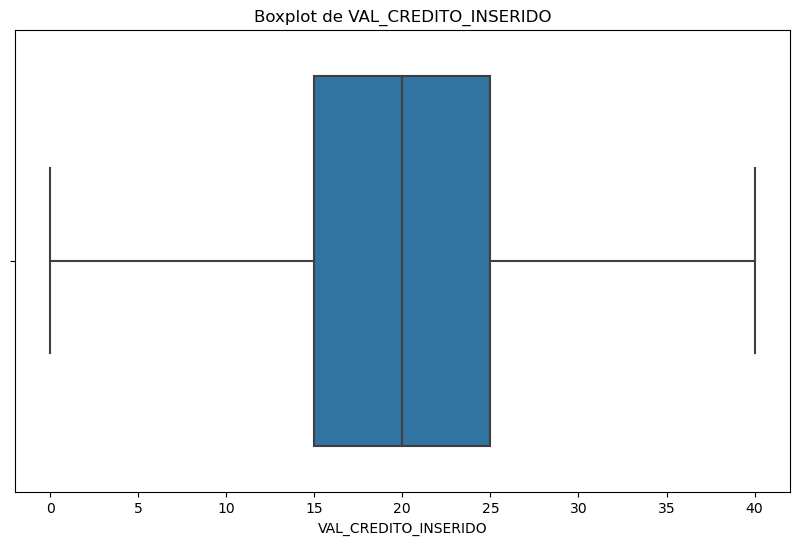

In [25]:
# Gerando boxplot para VAL_CREDITO_INSERIDO
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_base_recarga_selecionada['VAL_CREDITO_INSERIDO'])
plt.title('Boxplot de VAL_CREDITO_INSERIDO')
plt.show()

#### Criação das visões agregadas por SAFRA e CPF

In [26]:
df_base_recarga_selecionada_agg = df_base_recarga_selecionada.groupby(['NUM_CPF', 'SAFRA']).agg(
    QTDE_RECARGAS=('NUM_CPF', 'size'),
    QTDE_NUMEROS=('DW_NUM_NTC', 'nunique'),
    VAL_CREDITO_INSERIDO=('VAL_CREDITO_INSERIDO', 'sum'),
    VAL_BONUS=('VAL_BONUS', 'sum'),
    VAL_REAL=('VAL_REAL', 'sum'),
    QTD_SOS=('FLAG_SOS', 'sum'),
    VALOR_SOS=('VALOR_SOS', 'sum'),
).reset_index()

# ─── TRATAMENTO DE OUTLIERS ───────────────────────────────────────────────────

df_base_recarga_selecionada_agg['FLAG_ESTORNO_BONUS'] = (df_base_recarga_selecionada_agg['VAL_BONUS'] < 0).astype(int)
df_base_recarga_selecionada_agg['FLAG_ESTORNO_REAL']  = (df_base_recarga_selecionada_agg['VAL_REAL'] < 0).astype(int)
df_base_recarga_selecionada_agg['VAL_BONUS'] = df_base_recarga_selecionada_agg['VAL_BONUS'].clip(lower=0)
df_base_recarga_selecionada_agg['VAL_REAL']  = df_base_recarga_selecionada_agg['VAL_REAL'].clip(lower=0)

from scipy.stats import mstats
cols_winsori = ['QTDE_RECARGAS', 'VAL_CREDITO_INSERIDO', 'VAL_BONUS', 'VAL_REAL', 'VALOR_SOS']
for col in cols_winsori:
    df_base_recarga_selecionada_agg[col] = mstats.winsorize(df_base_recarga_selecionada_agg[col], limits=[0.01, 0.01])

# ─── FEATURE ENGINEERING ─────────────────────────────────────────────────────

df_base_recarga_selecionada_agg['TICKET_MEDIO_RECARGA'] = np.where(
    df_base_recarga_selecionada_agg['QTDE_RECARGAS'] > 0,
    df_base_recarga_selecionada_agg['VAL_CREDITO_INSERIDO'] / df_base_recarga_selecionada_agg['QTDE_RECARGAS'], 0)

df_base_recarga_selecionada_agg['RATIO_BONUS_CREDITO'] = np.where(
    df_base_recarga_selecionada_agg['VAL_CREDITO_INSERIDO'] > 0,
    df_base_recarga_selecionada_agg['VAL_BONUS'] / df_base_recarga_selecionada_agg['VAL_CREDITO_INSERIDO'], 0)

df_base_recarga_selecionada_agg['RATIO_REAL_CREDITO'] = np.where(
    df_base_recarga_selecionada_agg['VAL_CREDITO_INSERIDO'] > 0,
    df_base_recarga_selecionada_agg['VAL_REAL'] / df_base_recarga_selecionada_agg['VAL_CREDITO_INSERIDO'], 0)

df_base_recarga_selecionada_agg['RATIO_SOS_RECARGAS'] = np.where(
    df_base_recarga_selecionada_agg['QTDE_RECARGAS'] > 0,
    df_base_recarga_selecionada_agg['QTD_SOS'] / df_base_recarga_selecionada_agg['QTDE_RECARGAS'], 0)

df_base_recarga_selecionada_agg['TICKET_MEDIO_SOS'] = np.where(
    df_base_recarga_selecionada_agg['QTD_SOS'] > 0,
    df_base_recarga_selecionada_agg['VALOR_SOS'] / df_base_recarga_selecionada_agg['QTD_SOS'], 0)

df_base_recarga_selecionada_agg['FLAG_MULTI_NUMERO']  = (df_base_recarga_selecionada_agg['QTDE_NUMEROS'] > 1).astype(int)
df_base_recarga_selecionada_agg['FLAG_TEVE_ESTORNO']  = ((df_base_recarga_selecionada_agg['FLAG_ESTORNO_BONUS'] == 1) | (df_base_recarga_selecionada_agg['FLAG_ESTORNO_REAL'] == 1)).astype(int)
df_base_recarga_selecionada_agg['FLAG_SEM_RECARGA']   = (df_base_recarga_selecionada_agg['QTDE_RECARGAS'] == 0).astype(int)

print('Shape:', df_base_recarga_selecionada_agg.shape)
print(df_base_recarga_selecionada_agg.describe())

Shape: (9800281, 19)


C:\Users\alexandre.junior\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\alexandre.junior\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\alexandre.junior\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\alexandre.junior\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\alexandre.junior\AppData\Roaming\Python\Python311\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


       QTDE_RECARGAS  QTDE_NUMEROS  VAL_CREDITO_INSERIDO     VAL_BONUS  \
count   9.800281e+06  9.800281e+06          9.800281e+06  9.800281e+06   
mean    1.906831e+00  1.155000e+00          3.544387e+01  1.070337e+03   
std     1.356046e+00  4.271722e-01          2.262871e+01  6.632656e+03   
min     1.000000e+00  1.000000e+00          0.000000e+00  0.000000e+00   
25%     1.000000e+00  1.000000e+00          2.000000e+01  0.000000e+00   
50%     1.000000e+00  1.000000e+00          3.000000e+01  0.000000e+00   
75%     2.000000e+00  1.000000e+00          4.000000e+01  0.000000e+00   
max     8.000000e+00  2.100000e+01          1.250000e+02  4.220000e+04   

           VAL_REAL    QTD_SOS  VALOR_SOS  FLAG_ESTORNO_BONUS  \
count  9.800281e+06  9800281.0  9800281.0        9.800281e+06   
mean   1.105987e+03        0.0        0.0        1.080581e-04   
std    6.631732e+03        0.0        0.0        1.039454e-02   
min    0.000000e+00        0.0        0.0        0.000000e+00   
25%    2

In [27]:
df_base_recarga_selecionada_agg

,NUM_CPF,SAFRA,QTDE_RECARGAS,QTDE_NUMEROS,VAL_CREDITO_INSERIDO,VAL_BONUS,VAL_REAL,QTD_SOS,VALOR_SOS,FLAG_ESTORNO_BONUS,FLAG_ESTORNO_REAL,TICKET_MEDIO_RECARGA,RATIO_BONUS_CREDITO,RATIO_REAL_CREDITO,RATIO_SOS_RECARGAS,TICKET_MEDIO_SOS,FLAG_MULTI_NUMERO,FLAG_TEVE_ESTORNO,FLAG_SEM_RECARGA
0,777777UWTYZ,202310,1,1,30.0,0.0,30.0,0,0.0,0,0,30.000,0.00,1.00,0.0,0.0,0,0,0
1,777777UWTYZ,202311,2,2,50.0,0.0,50.0,0,0.0,0,0,25.000,0.00,1.00,0.0,0.0,1,0,0
2,777777UWTYZ,202401,1,1,20.0,0.0,20.0,0,0.0,0,0,20.000,0.00,1.00,0.0,0.0,0,0,0
3,777777UWTYZ,202402,2,2,50.0,0.0,50.0,0,0.0,0,0,25.000,0.00,1.00,0.0,0.0,1,0,0
4,777777UWTYZ,202403,1,1,30.0,0.0,30.0,0,0.0,0,0,30.000,0.00,1.00,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9800276,ZZZZZZZZY7Y,202411,8,18,125.0,0.0,555.0,0,0.0,0,0,15.625,0.00,4.44,0.0,0.0,1,0,0
9800277,ZZZZZZZZY7Y,202412,8,19,125.0,0.0,685.0,0,0.0,0,0,15.625,0.00,5.48,0.0,0.0,1,0,0
9800278,ZZZZZZZZY7Y,202501,8,20,125.0,20.0,600.0,0,0.0,0,0,15.625,0.16,4.80,0.0,0.0,1,0,0
9800279,ZZZZZZZZY7Y,202502,8,14,125.0,20.0,440.0,0,0.0,0,0,15.625,0.16,3.52,0.0,0.0,1,0,0


## Construção do Book Comportamental por SAFRA (Modelo de Crédito)

Este processo tem como objetivo a construção de um **book comportamental temporal** para modelagem de crédito, alinhado à predição de **FPD (First Payment Default)**.

### Visão Geral
Os dados comportamentais são inicialmente agregados no nível **CPF + SAFRA**, representando o comportamento observado em cada período mensal. A partir dessa base agregada, são criadas features históricas que capturam o comportamento passado do cliente em relação à **safra de referência**.

A base final do modelo é obtida por meio de um **LEFT JOIN** entre:
- **Base alvo (label)**: CPF + SAFRA com indicador FPD (0/1)
- **Base comportamental enriquecida**: histórico anterior ao mês da SAFRA

### Construção das Features Temporais
Para cada CPF, os dados são ordenados cronologicamente por SAFRA e são criadas defasagens temporais (*lags*) utilizando apenas informações do passado:

- Safra imediatamente anterior (t-1)
- Acumulado das últimas 3 safras (t-1 a t-3)
- Acumulado das últimas 6 safras (t-1 a t-6)

As defasagens são geradas via `groupby(CPF)` com `shift`, garantindo que **nenhuma informação da própria safra ou futura seja utilizada**, evitando vazamento temporal (*data leakage*).

### Robustez e Tratamento de Casos Especiais
- CPFs sem histórico anterior permanecem na base (LEFT JOIN), com valores nulos ou zerados.
- A ausência de histórico é considerada informação relevante para o modelo.
- O método é robusto a safras faltantes (meses sem registro), utilizando apenas o histórico efetivamente disponível.

### Garantias do Processo
- As features refletem exclusivamente o comportamento conhecido **até o momento da decisão de crédito**.
- A estrutura é reproduzível, auditável e adequada para uso em modelos supervisionados.
- O book final está preparado para técnicas de modelagem estatística e de machine learning.

Este desenho segue práticas consolidadas de modelagem de risco de crédito e permite expansão futura com métricas adicionais (médias, tendências, taxas e flags de histórico).


In [28]:
variaveis = [
    'QTDE_RECARGAS',
    'QTDE_NUMEROS',
    'VAL_CREDITO_INSERIDO',
    'VAL_BONUS',
    'VAL_REAL',
    'QTD_SOS',
    'VALOR_SOS'
]

df_book_04 = funcoes.criar_lags_por_safra(
    df=df_base_recarga_selecionada_agg,
    col_cpf='NUM_CPF',
    col_safra='SAFRA',
    variaveis=variaveis,
    janelas=[1, 3, 6]
)

In [29]:
book_04 = df_book_04.copy()

In [30]:
book_04 = pd.merge(
    book_03,
    df_book_04,
    on=['NUM_CPF', 'SAFRA'],
    how='left'
)

In [31]:
book_04

,SAFRA,FPD,SCORE_01,SCORE_02,NUM_CPF,SCORE_RATEO,SCORE_AVG,SCORE_DIFF,SCORE_MIN,DATADENASCIMENTO,...,VAL_BONUS_ULT_6_SAFRAS,VAL_REAL_ULT_1_SAFRAS,VAL_REAL_ULT_3_SAFRAS,VAL_REAL_ULT_6_SAFRAS,QTD_SOS_ULT_1_SAFRAS,QTD_SOS_ULT_3_SAFRAS,QTD_SOS_ULT_6_SAFRAS,VALOR_SOS_ULT_1_SAFRAS,VALOR_SOS_ULT_3_SAFRAS,VALOR_SOS_ULT_6_SAFRAS
0,202410,0,562.0,636.0,ZZZZZX7XWY8,1.131673,599.0,74.0,562.0,1983-12-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202410,1,546.0,518.0,ZZZZZX88YXY,0.948718,532.0,-28.0,518.0,1980-12-24,...,20.0,40.0,117.0,167.0,0.0,0.0,0.0,0.0,0.0,0.0
2,202410,0,621.0,750.0,ZZZZZYT7XYT,1.207729,685.5,129.0,621.0,1982-07-23,...,0.0,25.0,25.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
3,202410,1,609.0,679.0,ZZZZZNTXY9Z,1.114943,644.0,70.0,609.0,1988-09-27,...,0.0,85.0,160.0,235.0,0.0,0.0,0.0,0.0,0.0,0.0
4,202410,0,621.0,722.0,ZZZZZ79ZXUX,1.162641,671.5,101.0,621.0,1984-08-04,...,42200.0,42220.0,42240.0,42240.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280823,202503,0,604.0,674.0,99997YWXNZZ,1.115894,639.0,70.0,604.0,1960-01-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1280824,202503,0,688.0,765.0,99998TYXZN8,1.111919,726.5,77.0,688.0,1982-12-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1280825,202503,0,616.0,630.0,9999888YYU9,1.022727,623.0,14.0,616.0,1988-12-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1280826,202503,0,627.0,649.0,9999889ZN9X,1.035088,638.0,22.0,627.0,1963-09-15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
book_04['REGIAO_POSTAL_TXT'].value_counts()

Nordeste Setentrional (CE, PI, MA)    186867
Centro-Oeste e Norte                  163603
Interior de São Paulo                 150548
Grande São Paulo                      145821
Rio de Janeiro e Espírito Santo       140769
Nordeste Oriental (PE, AL, PB, RN)    120446
Bahia e Sergipe                       108227
Minas Gerais                           81622
Desconhecido                           74605
Rio Grande do Sul                      54266
Paraná e Santa Catarina                54054
Name: REGIAO_POSTAL_TXT, dtype: int64

In [ ]:
# Iremos manter no nosso dataset apenas o SCORE_2, iremos fazer o drop das colunas SCORE_1 SCORE_MIN
book_04.drop(columns=['SCORE_01', 'SCORE_MIN', 'SCORE_RATEO', 'SCORE_AVG', 'DATA_SAFRA', 'DATA_SAFRA'], inplace=True)



In [36]:
# De:
book_04['CEP_3_digitos'] = book_04['CEP_3_digitos'].astype('Int64')

# Para:
book_04['CEP_3_digitos'] = book_04['CEP_3_digitos'].astype('float64')  # float aceita NaN nativamente

In [37]:
book_04.to_parquet(project_root/'database/processed/book_variaveis_04.parquet', index=False)